In [34]:
"""
CST8506 Lab 4: Time Series Analysis
Author: Peng Wang
Student Number: 041107730

This lab analyses the Melbourne daily minimum temperature dataset using neural networks.
Part 1 builds a Dense model and a SimpleRNN model to forecast weekly average temperatures.
Part 2 (Naive Bayes) is handwritten and included in the answer document.
"""

# ============================================================
# 导入库
# Import Libraries
# ============================================================

# 导入标准库模块
# Import standard library modules
import os
from datetime import datetime

# 禁用 TensorFlow 警告信息（必须在导入 TensorFlow 之前设置）
# Disable TensorFlow warning messages (must be set before importing TensorFlow)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

# 导入科学计算和可视化库
# Import scientific computing and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 导入环境变量加载库
# Import environment variable loading library
from dotenv import load_dotenv

# 导入统计分解库
# Import statistical decomposition library
from statsmodels.tsa.seasonal import seasonal_decompose

# 导入 TensorFlow 和 Keras 模块
# Import TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout, Flatten
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [35]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
# 随机种子：学号后三位 041107730
# Random seed: last 3 digits of student number 041107730
SEED = 730

# 输出目录
# Output directory
OUTPUT_DIR = 'lab4_images'

# 数据文件路径
# Data file path
DATA_FILE = 'daily-minimum-temperatures-in-me.csv'

# 时间序列窗口大小（用前12周预测下一周）
# Time series window size (use past 12 weeks to predict next week)
WINDOW_SIZE = 12

# 训练轮数（要求至少20轮）
# Number of training epochs (at least 20 required)
EPOCHS = 30

# 每批次训练样本数量（32是个经验值，兼顾显卡内存和计算速度）
# Number of training samples per batch (32 is empirical sweet spot)
BATCH_SIZE = 32

# 训练集/测试集划分比例（80%训练 / 20%测试）
# Train/test split ratio (80% train / 20% test)
TRAIN_RATIO = 0.8

# Dense模型第一个层神经元数（选2的倍数是因为底层显卡算得最快）
# Number of neurons in Dense model first hidden layer (power of 2 for efficiency)
DENSE_UNITS_1 = 64

# Dense模型第二个层神经元数（数量减半，帮模型浓缩归纳重点特征）
# Number of neurons in Dense model second hidden layer (decreasing to extract features)
DENSE_UNITS_2 = 32

# RNN模型第一个层单元数（选2的倍数，底层显卡算得最快）
# Number of units in RNN model first SimpleRNN layer (power of 2 for efficiency)
RNN_UNITS_1 = 64

# RNN模型第二个单元数（数量减半，帮模型浓缩重点时间特征）
# Number of units in RNN model second SimpleRNN layer (decreasing to compress info)
RNN_UNITS_2 = 32

# Dropout比率（每层后随机“遮住”20%的神经元，防范模型死记硬背数据）
# Dropout rate (drop 20% neurons to prevent rote memorization)
DROPOUT_RATE = 0.2

# 季节性分解周期（52周 = 1年）
# Seasonal decomposition period (52 weeks = 1 year)
SEASONAL_PERIOD = 52

# 图表 DPI（图片分辨率）
# Plot DPI (image resolution)
PLOT_DPI = 150

# 分隔线宽度
# Divider line width
LINE_WIDTH = 60

In [36]:
# ============================================================
# 环境设置
# Environment Setup
# ============================================================
# 加载环境变量
# Load environment variables
load_dotenv('.env.local')
STUDENT_NAME = os.getenv('NAME', 'Peng Wang')
STUDENT_NUMBER = os.getenv('NUMBER', '041107730')

# 设置随机种子以确保结果可重复
# Set random seeds to ensure reproducible results
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 创建输出目录
# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 设置 pandas 显示选项
# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

# 打印实验信息
# Print lab information
current_date = datetime.now().strftime('%Y-%m-%d')
print("=" * LINE_WIDTH)
print("CST8506 - Lab 4: Time Series Analysis")
print(f"Author: {STUDENT_NAME}")
print(f"Student Number: {STUDENT_NUMBER}")
print(f"Date: {current_date}")
print(f"Random Seed: {SEED}")
print("=" * LINE_WIDTH)

CST8506 - Lab 4: Time Series Analysis
Author: Peng Wang
Student Number: 041107730
Date: 2026-02-24
Random Seed: 730


In [37]:
# ============================================================
# 步骤 1：加载数据集
# Step 1: Load the Dataset
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 1: Load the Dataset")
print("=" * LINE_WIDTH)

# 从本地 CSV 文件加载数据
# Load data from local CSV file
df = pd.read_csv(DATA_FILE)

# 打印数据集基本信息
# Print basic dataset information
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())


Step 1: Load the Dataset
Dataset shape: (3650, 2)
Columns: ['Date', 'Temp']
Date range: 1981-01-01 to 1990-12-31

First 5 rows:
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


In [38]:
# ============================================================
# 步骤 2：将日数据转换为周平均值
# Step 2: Convert Daily Data to Weekly Averages
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 2: Convert Daily Data to Weekly Averages")
print("=" * LINE_WIDTH)

# 将 Date 列转换为 datetime 格式并设为索引
# Convert Date column to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 使用 resample('W') 将日数据转为周平均值
# Use resample('W') to convert daily data to weekly averages
weekly_data = df['Temp'].resample('W').mean()

# 删除可能的缺失值
# Drop any missing values
weekly_data = weekly_data.dropna()

# 打印前 5 个周平均实例
# Print the first 5 weekly average instances
print(f"Original daily records: {len(df)}")
print(f"Weekly average records: {len(weekly_data)}")
print(f"\nFirst 5 weekly averages:")
print(weekly_data.head())


Step 2: Convert Daily Data to Weekly Averages
Original daily records: 3650
Weekly average records: 523

First 5 weekly averages:
Date
1981-01-04    18.000000
1981-01-11    17.542857
1981-01-18    20.371429
1981-01-25    15.771429
1981-02-01    16.657143
Freq: W-SUN, Name: Temp, dtype: float64



Step 3: Plot Weekly Average Temperature Series


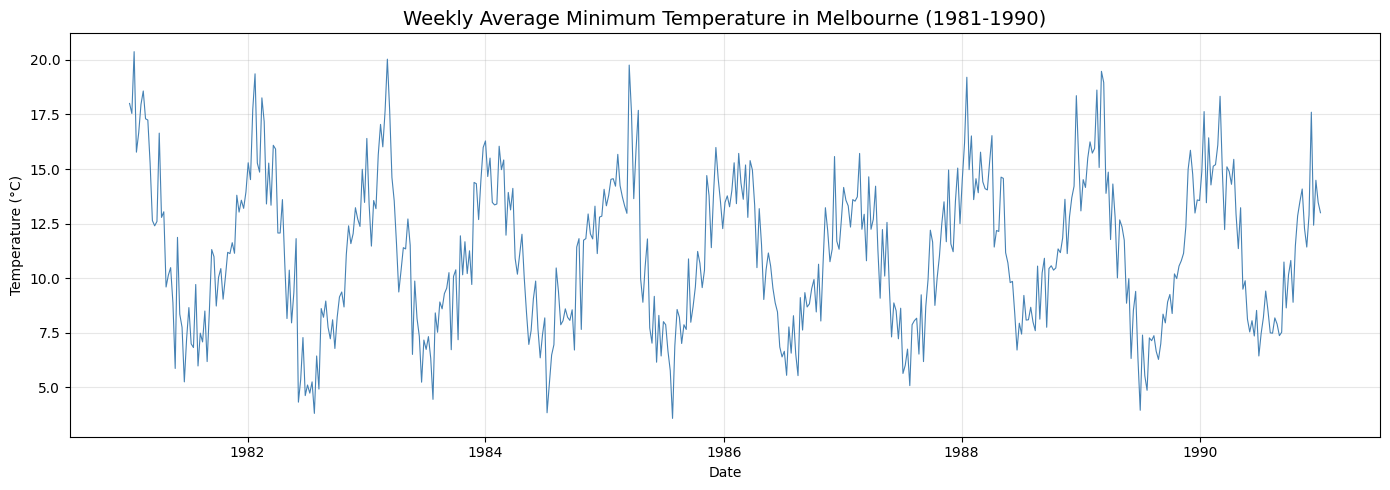

Weekly temperature plot saved.
Temperature range: 3.59°C to 20.37°C


In [39]:
# ============================================================
# 步骤 3：绘制周平均气温序列
# Step 3: Plot Weekly Average Temperature Series
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 3: Plot Weekly Average Temperature Series")
print("=" * LINE_WIDTH)

# 绘制完整的周平均气温时间序列
# Plot the full weekly average temperature time series
plt.figure(figsize=(14, 5))
plt.plot(weekly_data.index, weekly_data.values, color='steelblue', linewidth=0.8)
plt.title('Weekly Average Minimum Temperature in Melbourne (1981-1990)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 保存图表到输出目录
# Save plot to output directory
plt.savefig(os.path.join(OUTPUT_DIR, 'step03_weekly_temperature.png'), dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

print("Weekly temperature plot saved.")
print(f"Temperature range: {weekly_data.min():.2f}°C to {weekly_data.max():.2f}°C")


Step 4: Plot Seasonal Decomposition


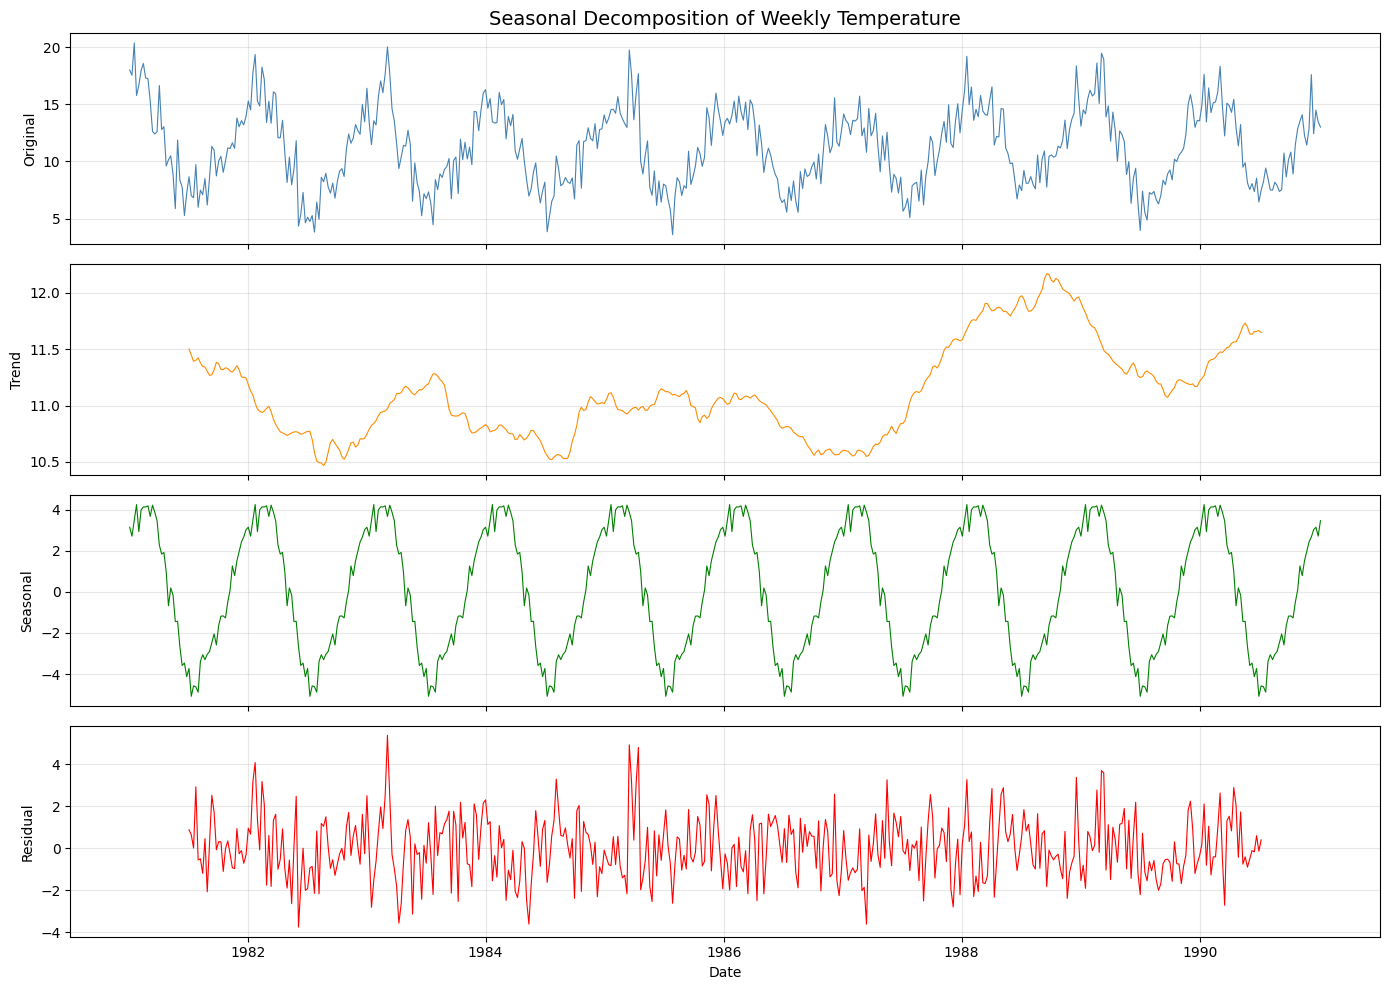

Seasonal decomposition plot saved.
Decomposition model: Additive
Period: 52 weeks (1 year)


In [40]:
# ============================================================
# 步骤 4：绘制季节性分解图
# Step 4: Plot Seasonal Decomposition (Original, Trend, Seasonal, Residue)
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 4: Plot Seasonal Decomposition")
print("=" * LINE_WIDTH)

# ================================================================
# 源码解析：加法季节性分解（seasonal_decompose）
# Source Analysis: Additive Seasonal Decomposition
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   statsmodels/tsa/seasonal.py → def seasonal_decompose
#   https://github.com/statsmodels/statsmodels/blob/main/statsmodels/tsa/seasonal.py
#
# What:
#   将时间序列拆分为趋势(Trend)、季节性(Seasonal)、残差(Residual) 三个成分
#   Decomposes a time series into Trend, Seasonal, and Residual components
#
# Why:
#   原始序列混合了长期走势、周期波动和随机噪声，分解后才能分别分析各个规律
#   Raw series mixes long-term trends, periodic cycles, and noise; decomposition separates them for individual analysis
#
# How:
#   源码核心逻辑（简化版）：
#   trend = convolution_filter(x, weights)        # 移动平均提取趋势
#   detrended = x - trend                         # 减去趋势
#   seasonal = np.mean(detrended.reshape(-1, period), axis=0)  # 按周期位置求均值
#   residual = x - trend - seasonal               # 残差 = 原始 - 趋势 - 季节
#
#   举例（假设 period=4, 数据=[10,20,12,22, 11,21,13,23]）：
#   trend ≈ [16, 16, 16, 17, ...]（移动平均抹平波动）
#   seasonal ≈ [-5, +5, -3, +5]（每个周期位置的固定偏差）
#   residual ≈ [-1, -1, -1, 0, ...]（剩余随机噪声）
#   加法分解：observed = trend + seasonal + residual
#   Additive decomposition: observed = trend + seasonal + residual
#
# API:
#   签名: seasonal_decompose(x, model='additive', period=None, ...)
#   用法: seasonal_decompose(weekly_data, model='additive', period=52)
#   'additive' 因为气温波动幅度每年固定，不会随趋势成比例扩大
#   period=52 表示以 52 周（1年）为一个完整周期
#   'additive' because temperature fluctuation amplitude is constant yearly
#   period=52 means one full cycle = 52 weeks (1 year)
# ================================================================
decomposition = seasonal_decompose(weekly_data, model='additive', period=SEASONAL_PERIOD)

# 创建 4 个子图显示分解结果
# Create 4 subplots to show decomposition results
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# 原始数据
# Original data
axes[0].plot(decomposition.observed, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Original')
axes[0].set_title('Seasonal Decomposition of Weekly Temperature', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 趋势成分
# Trend component
axes[1].plot(decomposition.trend, color='darkorange', linewidth=0.8)
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# 季节性成分
# Seasonal component
axes[2].plot(decomposition.seasonal, color='green', linewidth=0.8)
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# 残差成分
# Residual component
axes[3].plot(decomposition.resid, color='red', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'step04_decomposition.png'), dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

print("Seasonal decomposition plot saved.")
print(f"Decomposition model: Additive")
print(f"Period: {SEASONAL_PERIOD} weeks (1 year)")

In [41]:
# ============================================================
# 步骤 5：生成训练和测试时间序列序列
# Step 5: Generate Train and Test Time Series Sequences
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 5: Generate Train and Test Time Series Sequences")
print("=" * LINE_WIDTH)

# 获取温度值数组
# Get temperature values array
temp_values = weekly_data.values.reshape(-1, 1)

# 按 80/20 比例划分训练/测试集
# Split train/test by 80/20 ratio
split_index = int(len(temp_values) * TRAIN_RATIO)
train_data = temp_values[:split_index]
test_data = temp_values[split_index:]

print(f"Total weekly data points: {len(temp_values)}")
print(f"Training data: {len(train_data)} weeks")
print(f"Test data: {len(test_data)} weeks")
print(f"Window size: {WINDOW_SIZE} weeks")


Step 5: Generate Train and Test Time Series Sequences
Total weekly data points: 523
Training data: 418 weeks
Test data: 105 weeks
Window size: 12 weeks


In [42]:
# ============================================================
# 步骤 6：数据归一化
# Step 6: Normalize the Data
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 6: Normalize the Data")
print("=" * LINE_WIDTH)

# 使用训练集的最小值和最大值进行归一化（防止数据泄漏）
# Normalize using training set min and max (prevents data leakage)
train_min = train_data.min()
train_max = train_data.max()

# 对训练集和测试集进行归一化
# Normalize both training and test sets
train_normalized = (train_data - train_min) / (train_max - train_min)
test_normalized = (test_data - train_min) / (train_max - train_min)

print(f"Training data - Min: {train_min:.2f}, Max: {train_max:.2f}")
print(f"Normalized training - Min: {train_normalized.min():.4f}, Max: {train_normalized.max():.4f}")
print(f"Normalized test - Min: {test_normalized.min():.4f}, Max: {test_normalized.max():.4f}")

# ================================================================
# 源码解析：时间序列样本生成器（TimeseriesGenerator）
# Source Analysis: TimeseriesGenerator
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   keras/src/legacy/preprocessing/sequence.py → class TimeseriesGenerator
#   https://github.com/keras-team/keras/blob/main/keras/src/legacy/preprocessing/sequence.py
#
# What:
#   把一整条时间序列自动切成"前N步→预测下一步"的固定大小样本对
#   Auto-slices a time series into fixed-size "past N steps → predict next" sample pairs
#
# Why:
#   神经网络不能直接吃一整条长度不定的序列，必须切成固定窗口喂进去
#   Neural networks require fixed-size inputs, not variable-length sequences
#
# How:
#   源码 __getitem__ 核心逻辑（简化版）：
#   for row in rows:
#       samples.append( data[row - length : row] )
#       targets.append( targets[row] )
#
#   举例（data=[10,11,12,13,14,15], length=3）：
#   row=3 → input=[10,11,12], target=13
#   row=4 → input=[11,12,13], target=14
#   row=5 → input=[12,13,14], target=15
#   窗口每次前移一步，取前3个预测下一个
#   Window slides forward one step, takes 3 past points to predict the next
#
# API:
#   签名: TimeseriesGenerator(data, targets, length, sampling_rate=1, stride=1, batch_size=128, ...)
#   用法: TimeseriesGenerator(train_normalized, train_normalized, length=WINDOW_SIZE, batch_size=BATCH_SIZE)
#   data 和 targets 传同一个数组 = 自回归（用 past 预测 future）
#   Same array for data & targets = autoregressive (predict future from past)
# ================================================================
train_generator = TimeseriesGenerator(train_normalized, train_normalized,
                                       length=WINDOW_SIZE, batch_size=BATCH_SIZE)
test_generator = TimeseriesGenerator(test_normalized, test_normalized,
                                      length=WINDOW_SIZE, batch_size=BATCH_SIZE)

print(f"\nTimeseriesGenerator created:")
print(f"  Window size: {WINDOW_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(train_generator)}")
print(f"  Test batches: {len(test_generator)}")


Step 6: Normalize the Data
Training data - Min: 3.59, Max: 20.37
Normalized training - Min: 0.0000, Max: 1.0000
Normalized test - Min: 0.0221, Max: 0.9464

TimeseriesGenerator created:
  Window size: 12
  Batch size: 32
  Training batches: 13
  Test batches: 3


In [43]:
# ============================================================
# 步骤 7：构建 Dense 神经网络模型
# Step 7: Build Dense Neural Network Model
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 7: Build Dense Neural Network Model")
print("=" * LINE_WIDTH)

# ================================================================
# 源码解析：顺序模型（Sequential）
# Source Analysis: Sequential Model
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   keras/src/models/sequential.py → class Sequential
#   https://github.com/keras-team/keras/blob/main/keras/src/models/sequential.py
#
# What:
#   将多个层按顺序串联成单输入单输出的直线型流水线
#   Chains layers into a single-input single-output linear pipeline
#
# Why:
#   把 Flatten → Dense → Dense → Dense 四步串成一个完整模型，统一管理训练和预测
#   Chains Flatten → Dense → Dense → Dense into one model for unified training and prediction
#
# How:
#   源码 __init__ / add() 核心逻辑：
#   for layer in layers:
#       self._layers.append(layer)    # 按顺序存入列表
#   前向传播（__call__）时：
#   for layer in self._layers:
#       x = layer(x)                  # 依次调用每层，输出传给下一层
#
#   举例（本模型的数据流）：
#   input(12,1) → Flatten → (12,) → Dense64 → (64,) → Dense32 → (32,) → Dense1 → (1,)
#   数据逐层变换，最终输出一个温度预测值
#   Data transforms layer by layer, finally outputs a single temperature prediction
#
# API:
#   签名: Sequential(layers=None, name=None)
#   用法: Sequential([Flatten(...), Dense(...), Dense(...), Dense(1)])
#   传入层的列表，Sequential 自动按顺序串联
#   Pass a list of layers, Sequential chains them in order automatically
# ================================================================
dense_model = Sequential([
    # ================================================================
    # 源码解析：展平层（Flatten）
    # Source Analysis: Flatten Layer
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/reshaping/flatten.py → class Flatten
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/reshaping/flatten.py
    #
    # What:
    #   将多维输入展平为一维向量（保留 batch 维度）
    #   Flattens multi-dimensional input into a 1D vector (keeps batch dimension)
    #
    # Why:
    #   Dense 层只能接受一维输入，TimeseriesGenerator 输出的 (12,1) 需要先展平成 (12,)
    #   Dense layers only accept 1D input; TimeseriesGenerator outputs (12,1) which must be flattened to (12,)
    #
    # How:
    #   源码 call() 核心逻辑：
    #   flattened_dim = math.prod(non_batch_dims)   # 将除 batch 外所有维度相乘
    #   return ops.reshape(inputs, (batch_size, flattened_dim))
    #
    #   举例（input_shape=(12, 1)）：
    #   flattened_dim = 12 × 1 = 12
    #   (batch, 12, 1) → (batch, 12)
    #   12个周的温度从二维矩阵变成一维数组
    #   12 weeks of temperatures go from 2D matrix to 1D array
    #
    # API:
    #   签名: Flatten(data_format=None)
    #   用法: Flatten(input_shape=(WINDOW_SIZE, 1))
    #   input_shape=(12,1) 告诉模型第一层的输入形状
    #   input_shape=(12,1) tells the model the input shape for the first layer
    # ================================================================
    Flatten(input_shape=(WINDOW_SIZE, 1)),

    # ================================================================
    # 源码解析：全连接层（Dense）— 特征提取
    # Source Analysis: Dense Layer — Feature Extraction
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/core/dense.py → class Dense
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/core/dense.py
    #
    # What:
    #   每个神经元与所有输入做加权求和（矩阵乘法）+ 偏置 + 激活函数
    #   Each neuron computes weighted sum (matrix multiply) of all inputs + bias + activation
    #
    # Why:
    #   将 12 个温度值进行非线性组合，提取出温度变化的隐含模式
    #   Non-linearly combines 12 temperature values to extract hidden patterns of temperature change
    #
    # How:
    #   源码 call() 核心逻辑：
    #   x = ops.matmul(inputs, self.kernel)   # 矩阵乘法: (12,) × (12,64) → (64,)
    #   x = ops.add(x, self.bias)             # 加偏置: (64,) + (64,) → (64,)
    #   x = self.activation(x)                # ReLU: max(0, x)
    #
    #   举例（输入=[0.2, 0.5, ...] 共12个, units=64）：
    #   每个神经元 = 12个输入的加权和 + 偏置，再过 ReLU
    #   neuron_1 = relu(0.2×w1 + 0.5×w2 + ... + bias)
    #   共 64 个这样的神经元并行计算
    #   64 such neurons compute in parallel
    #
    # API:
    #   签名: Dense(units, activation=None, use_bias=True, ...)
    #   用法: Dense(64, activation='relu')
    #   64 个神经元提取特征，ReLU 引入非线性
    #   没有 ReLU，多层 Dense 等价于一层（只能拟合直线）
    #   64 neurons extract features, ReLU adds non-linearity
    #   Without ReLU, stacked Dense layers collapse to a single linear layer
    # ================================================================
    Dense(DENSE_UNITS_1, activation='relu'),

    # ================================================================
    # 源码解析：全连接层（Dense）— 特征压缩
    # Source Analysis: Dense Layer — Feature Compression
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/core/dense.py → class Dense
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/core/dense.py
    #
    # What:
    #   将上一层的 64 个特征压缩为 32 个更核心的特征
    #   Compresses the 64 features from the previous layer into 32 core features
    #
    # Why:
    #   递减神经元迫使网络筛选最重要的信息，去除冗余和噪声
    #   Decreasing neurons forces the network to keep only the most important info, removing redundancy and noise
    #
    # How:
    #   与上一层相同的逻辑，但 kernel 形状变为 (64, 32)：
    #   x = ops.matmul(inputs, self.kernel)   # (64,) × (64,32) → (32,)
    #   64 个特征被压缩筛选为 32 个
    #   64 features compressed and filtered into 32
    #
    # API:
    #   签名: Dense(units, activation=None, use_bias=True, ...)
    #   用法: Dense(32, activation='relu')
    #   32 < 64，形成"漏斗"结构，逐层提炼信息
    #   32 < 64 creates a "funnel" structure, refining information layer by layer
    # ================================================================
    Dense(DENSE_UNITS_2, activation='relu'),

    # ================================================================
    # 源码解析：全连接层（Dense）— 回归输出
    # Source Analysis: Dense Layer — Regression Output
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/core/dense.py → class Dense
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/core/dense.py
    #
    # What:
    #   输出单个数值，作为温度预测结果
    #   Outputs a single numerical value as the temperature prediction
    #
    # Why:
    #   预测"下一周气温"只需要一个数字，不需要分类概率
    #   Predicting "next week temperature" needs just one number, not class probabilities
    #
    # How:
    #   源码 call() 中 activation=None 时：
    #   x = ops.matmul(inputs, self.kernel)   # (32,) × (32,1) → (1,)
    #   x = ops.add(x, self.bias)             # (1,) + (1,) → (1,)
    #   # 跳过 activation，直接返回原始浮点数
    #   # activation step skipped, raw float returned directly
    #
    # API:
    #   签名: Dense(units, activation=None, ...)
    #   用法: Dense(1)
    #   units=1 输出一个值，无 activation 因为回归任务需要输出任意实数
    #   加 sigmoid 会限制在 0~1，不适合温度预测
    #   units=1 outputs one value, no activation because regression needs any real number
    #   Adding sigmoid would restrict to 0~1, unsuitable for temperature prediction
    # ================================================================
    Dense(1)
])

# 打印模型架构信息
# Print model architecture information
print("Dense Model Architecture:")
print(f"  Flatten: input_shape=({WINDOW_SIZE}, 1)")
print(f"  Dense Layer 1: {DENSE_UNITS_1} units, activation='relu'")
print(f"  Dense Layer 2: {DENSE_UNITS_2} units, activation='relu'")
print(f"  Output Layer: 1 unit, no activation (regression)")
print()
dense_model.summary()


Step 7: Build Dense Neural Network Model
Dense Model Architecture:
  Flatten: input_shape=(12, 1)
  Dense Layer 1: 64 units, activation='relu'
  Dense Layer 2: 32 units, activation='relu'
  Output Layer: 1 unit, no activation (regression)



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# ============================================================
# 步骤 8：编译和训练 Dense 模型
# Step 8: Compile and Fit the Dense Model
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 8: Compile and Fit the Dense Model")
print("=" * LINE_WIDTH)

# ================================================================
# 源码解析：模型编译（compile）
# Source Analysis: Model Compile
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   keras/src/trainers/trainer.py → Trainer.compile
#   https://github.com/keras-team/keras/blob/main/keras/src/trainers/trainer.py
#
# What:
#   将优化器、损失函数、评估指标三者绑定到模型上，为训练做准备
#   Binds optimizer, loss function, and metrics to the model, preparing it for training
#
# Why:
#   模型搭好了只是定义了"结构"，compile 告诉它"怎么学"（用什么方法优化、优化什么目标）
#   Building a model only defines "structure"; compile tells it "how to learn" (optimization method and target)
#
# How:
#   源码核心逻辑：
#   self.optimizer = optimizers.get(optimizer)     # 解析字符串 'adam' → Adam 对象
#   self.loss = losses.get(loss)                   # 解析 'mse' → MeanSquaredError 对象
#   self.metrics = [metrics.get(m) for m in metrics]  # 解析 ['mae'] → MeanAbsoluteError
#   三者存储在模型内部，等 fit() 时使用
#   All three stored internally, used when fit() is called
#
# API:
#   签名: compile(optimizer='rmsprop', loss=None, metrics=None, ...)
#   用法: compile(optimizer='adam', loss='mse', metrics=['mae'])
#   adam = 自适应学习率优化器，适合大多数任务
#   mse = 均方误差（回归任务的标准损失）
#   mae = 平均绝对误差（直观的温度偏差指标，单位是°C）
#   adam = adaptive learning rate optimizer, good for most tasks
#   mse = mean squared error (standard regression loss)
#   mae = mean absolute error (intuitive temperature deviation in °C)
# ================================================================
dense_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Compiled with: optimizer='adam', loss='mse', metrics=['mae']")
print(f"Training for {EPOCHS} epochs...")
print()

# ================================================================
# 源码解析：模型训练（fit）
# Source Analysis: Model Training (fit)
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   keras/src/trainers/trainer.py → Trainer.fit
#   keras/src/backend/tensorflow/trainer.py → TensorFlowTrainer.train_step
#   https://github.com/keras-team/keras/blob/main/keras/src/trainers/trainer.py
#
# What:
#   执行完整的训练循环：逐批次取数据 → 前向传播 → 算损失 → 反向传播 → 更新权重
#   Runs the full training loop: fetch batches → forward pass → compute loss → backprop → update weights
#
# Why:
#   compile 只是"配置"，fit 才是"执行"——真正开始学习数据中的规律
#   compile only "configures"; fit actually "executes" — starts learning patterns from data
#
# How:
#   源码 train_step() 核心逻辑（每个 batch）：
#   y_pred = self(x, training=True)              # 前向传播：数据过模型得到预测
#   loss = self._compute_loss(y, y_pred)          # 算损失：预测 vs 真实的差距
#   gradients = tape.gradient(loss, weights)       # 反向传播：算每个权重对损失的贡献
#   optimizer.apply_gradients(zip(grads, weights)) # 更新权重：朝损失减小的方向调整
#
#   举例（epochs=30, 训练集有 ~390 个样本, batch_size=32）：
#   每轮 = ceil(390/32) ≈ 13 个 batch
#   共 30 轮 × 13 batch = ~390 次权重更新
#   30 epochs × 13 batches = ~390 weight updates total
#
# API:
#   签名: fit(x, y=None, batch_size=None, epochs=1, verbose='auto', ...)
#   用法: fit(train_generator, epochs=EPOCHS, verbose=2)
#   传入 generator 时不需要 y（generator 自动提供 input 和 target）
#   verbose=2 每轮打印一行摘要（0=静默, 1=进度条, 2=一行摘要）
#   Generator provides both input and target, so y is not needed
#   verbose=2 prints one summary line per epoch (0=silent, 1=progress bar, 2=one line)
# ================================================================
dense_history = dense_model.fit(train_generator, epochs=EPOCHS, verbose=2)


Step 8: Compile and Fit the Dense Model
Compiled with: optimizer='adam', loss='mse', metrics=['mae']
Training for 30 epochs...

Epoch 1/30


13/13 - 0s - 27ms/step - loss: 0.1929 - mae: 0.3816
Epoch 2/30
13/13 - 0s - 2ms/step - loss: 0.0368 - mae: 0.1551
Epoch 3/30
13/13 - 0s - 2ms/step - loss: 0.0305 - mae: 0.1386
Epoch 4/30
13/13 - 0s - 2ms/step - loss: 0.0212 - mae: 0.1173
Epoch 5/30
13/13 - 0s - 2ms/step - loss: 0.0150 - mae: 0.0975
Epoch 6/30
13/13 - 0s - 2ms/step - loss: 0.0124 - mae: 0.0870
Epoch 7/30
13/13 - 0s - 2ms/step - loss: 0.0114 - mae: 0.0834
Epoch 8/30
13/13 - 0s - 2ms/step - loss: 0.0110 - mae: 0.0814
Epoch 9/30
13/13 - 0s - 2ms/step - loss: 0.0108 - mae: 0.0806
Epoch 10/30
13/13 - 0s - 2ms/step - loss: 0.0106 - mae: 0.0805
Epoch 11/30
13/13 - 0s - 2ms/step - loss: 0.0106 - mae: 0.0799
Epoch 12/30
13/13 - 0s - 2ms/step - loss: 0.0104 - mae: 0.0798
Epoch 13/30
13/13 - 0s - 2ms/step - loss: 0.0103 - mae: 0.0796
Epoch 14/30
13/13 - 0s - 2ms/step - loss: 0.0102 - mae: 0.0790
Epoch 15/30
13/13 - 0s - 2ms/step - loss: 0.0101 - mae: 0.0788
Epoch 16/30
13/13 - 0s - 2ms/step - loss: 0.0102 - mae: 0.0788
Epoch 17/30

In [45]:
# ============================================================
# 步骤 9：Dense 模型预测测试数据
# Step 9: Predict for Test Data (Dense Model)
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 9: Predict for Test Data (Dense Model)")
print("=" * LINE_WIDTH)

# ================================================================
# 源码解析：模型预测（predict）
# Source Analysis: Model Prediction (predict)
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   keras/src/trainers/trainer.py → Trainer.predict
#   keras/src/backend/tensorflow/trainer.py → TensorFlowTrainer.predict_step
#   https://github.com/keras-team/keras/blob/main/keras/src/trainers/trainer.py
#
# What:
#   用训练好的模型对新数据做前向传播，输出预测结果
#   Runs forward pass on new data using the trained model to produce predictions
#
# Why:
#   训练完成后，用模型对测试集做预测，评估泛化能力
#   After training, use the model to predict on test set and evaluate generalization
#
# How:
#   源码 predict_step() 核心逻辑：
#   y_pred = self(x, training=False)   # 只做前向传播，不更新权重
#   return y_pred                       # 返回预测值
#   与 train_step 的区别：没有 loss 计算、没有梯度、没有权重更新
#   Difference from train_step: no loss computation, no gradients, no weight updates
#
# API:
#   签名: predict(x, batch_size=None, verbose='auto', ...)
#   用法: predict(test_generator, verbose=0)
#   verbose=0 禁用进度条（防止截图乱码）
#   verbose=0 disables progress bar (prevents garbled text in screenshots)
# ================================================================
dense_predictions_norm = dense_model.predict(test_generator, verbose=0)

# 反归一化预测结果：从 [0,1] 还原到原始温度值
# prediction × (max - min) + min = 原始温度
# Denormalize: prediction × (max - min) + min = original temperature
dense_predictions = dense_predictions_norm * (train_max - train_min) + train_min

print(f"Dense model predictions shape: {dense_predictions.shape}")
print(f"Prediction range: {dense_predictions.min():.2f}°C to {dense_predictions.max():.2f}°C")


Step 9: Predict for Test Data (Dense Model)
Dense model predictions shape: (93, 1)
Prediction range: 5.42°C to 16.73°C



Step 10: Plot Original Data and Dense Model Predictions


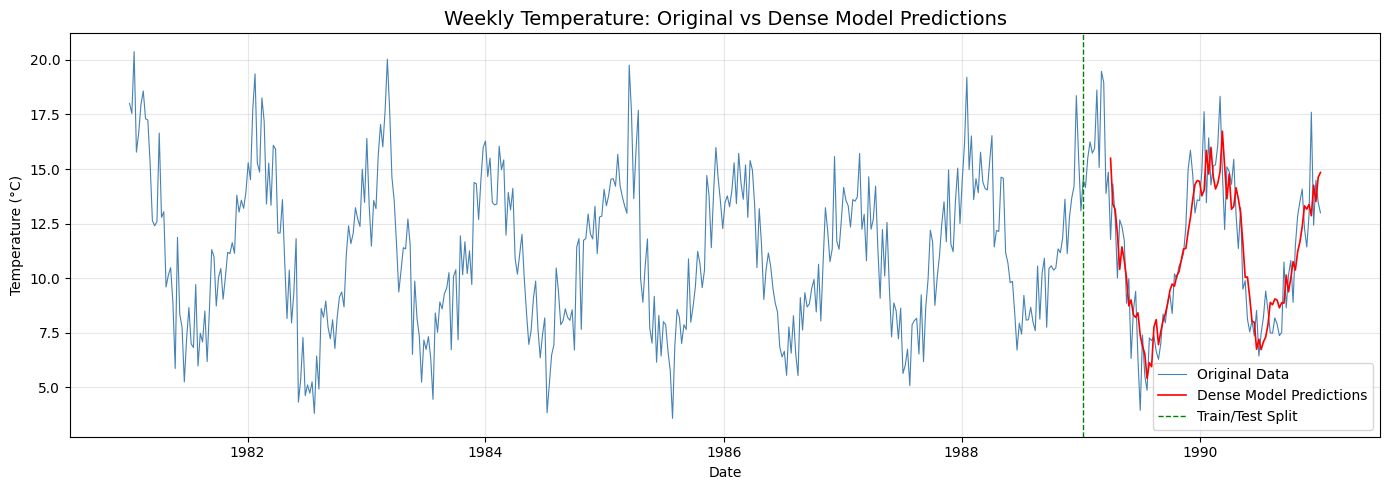

Dense prediction plot saved.


In [46]:
# ============================================================
# 步骤 10：绘制原始数据和 Dense 模型预测
# Step 10: Plot Original Data and Dense Model Predictions
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 10: Plot Original Data and Dense Model Predictions")
print("=" * LINE_WIDTH)

# 获取测试集对应的时间索引（偏移 WINDOW_SIZE）
# Get time index corresponding to test set (offset by WINDOW_SIZE)
test_time_index = weekly_data.index[split_index + WINDOW_SIZE:]

# 绘制原始数据和 Dense 预测结果
# Plot original data and Dense predictions
plt.figure(figsize=(14, 5))

# 蓝色：原始周平均气温
# Blue: original weekly average temperature
plt.plot(weekly_data.index, weekly_data.values, color='steelblue', linewidth=0.8, label='Original Data')

# 红色：Dense 模型预测
# Red: Dense model predictions
plt.plot(test_time_index[:len(dense_predictions)], dense_predictions.flatten(),
         color='red', linewidth=1.2, label='Dense Model Predictions')

# 绿色虚线：训练/测试分界线
# Green dashed line: train/test split boundary
plt.axvline(x=weekly_data.index[split_index], color='green', linestyle='--',
            linewidth=1.0, label='Train/Test Split')

plt.title('Weekly Temperature: Original vs Dense Model Predictions', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'step10_dense_predictions.png'), dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

print("Dense prediction plot saved.")

In [47]:
# ============================================================
# 步骤 11：构建 RNN 模型（SimpleRNN + Dropout）
# Step 11: Build RNN Model (SimpleRNN + Dropout)
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 11: Build RNN Model (SimpleRNN + Dropout)")
print("=" * LINE_WIDTH)

# ================================================================
# 源码解析：顺序模型（Sequential）— RNN 版本
# Source Analysis: Sequential Model — RNN Version
# ================================================================
#
# -------- Source Analysis --------
#
# Source:
#   keras/src/models/sequential.py → class Sequential
#   https://github.com/keras-team/keras/blob/main/keras/src/models/sequential.py
#
# What:
#   与 Dense 模型相同的 Sequential 容器，但内部层从 Dense 换成 SimpleRNN + Dropout
#   Same Sequential container as Dense model, but with SimpleRNN + Dropout layers inside
#
# Why:
#   RNN + Dense 混合架构：RNN 层提取时序模式，Dense 层做最终数值映射
#   RNN + Dense hybrid: RNN layers extract temporal patterns, Dense layers do final numerical mapping
#
# How:
#   数据流（与 Dense 模型对比）：
#   Dense:  input(12,1) → Flatten → (12,) → Dense → Dense → Dense(1)
#   RNN:    input(12,1) → SimpleRNN → Dropout → SimpleRNN → Dropout → Dense → Dense → Dense(1)
#   RNN 模型不需要 Flatten，因为 RNN 层天生接受 (timesteps, features) 格式
#   RNN model doesn't need Flatten because RNN layers natively accept (timesteps, features) format
#
# API:
#   签名: Sequential(layers=None, name=None)
#   用法: Sequential([SimpleRNN(...), Dropout(...), SimpleRNN(...), Dropout(...), Dense(...), Dense(...), Dense(1)])
# ================================================================
rnn_model = Sequential([
    # ================================================================
    # 源码解析：简单循环网络层（SimpleRNN）— 第一层
    # Source Analysis: SimpleRNN Layer — First Layer
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/rnn/simple_rnn.py → class SimpleRNN / SimpleRNNCell
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/rnn/simple_rnn.py
    #
    # What:
    #   按时间顺序逐步读取数据，每步综合"当前输入"和"上一步的记忆"更新内部状态
    #   Reads data step-by-step over time, combining "current input" and "previous memory" to update internal state
    #
    # Why:
    #   Dense 层把 12 周当作无序数字，RNN 保持时间顺序——能捕捉"先升后降"这样的时序规律
    #   Dense treats 12 weeks as unordered numbers; RNN preserves time order — can capture patterns like "rise then fall"
    #
    # How:
    #   源码 SimpleRNNCell.call() 核心逻辑（每个时间步）：
    #   h = ops.matmul(input_t, self.kernel)                        # 当前输入 × 输入权重
    #   output = h + ops.matmul(prev_output, self.recurrent_kernel)  # + 上一步输出 × 循环权重
    #   output = self.activation(output)                             # 激活函数
    #
    #   举例（读取12周温度, units=64）：
    #   步骤1: state = relu(week1 × W_input + zeros × W_recurrent)  # 第一周，无历史
    #   步骤2: state = relu(week2 × W_input + state1 × W_recurrent) # 综合第二周+第一周记忆
    #   ... 步骤12: state = relu(week12 × W + state11 × W)           # 包含前11周的累积记忆
    #   Step 1: no history; Step 12: contains accumulated memory of all 11 previous weeks
    #
    # API:
    #   签名: SimpleRNN(units, activation='tanh', return_sequences=False, ...)
    #   用法: SimpleRNN(64, activation='relu', return_sequences=True, input_shape=(12, 1))
    #   return_sequences=True 输出每个时间步的结果 (12, 64)，供下一层 RNN 继续处理
    #   return_sequences=True outputs at every timestep (12, 64), so the next RNN layer can process the sequence
    # ================================================================
    SimpleRNN(RNN_UNITS_1, activation='relu', return_sequences=True,
              input_shape=(WINDOW_SIZE, 1)),

    # ================================================================
    # 源码解析：随机失活层（Dropout）
    # Source Analysis: Dropout Layer
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/regularization/dropout.py → class Dropout
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/regularization/dropout.py
    #
    # What:
    #   训练时随机将一定比例的神经元输出设为 0，推理时不做任何事
    #   During training, randomly sets a fraction of neuron outputs to 0; does nothing during inference
    #
    # Why:
    #   RNN 拟合能力强，容易死记训练数据（过拟合）。Dropout 强迫网络在信息缺失时也能工作，提高泛化能力
    #   RNNs easily memorize training data (overfit). Dropout forces the network to work with missing info, improving generalization
    #
    # How:
    #   源码 call() 核心逻辑：
    #   if training and self.rate > 0:
    #       return backend.random.dropout(inputs, self.rate)  # 随机置 0 + 缩放
    #   return inputs                                          # 推理时原样返回
    #
    #   举例（rate=0.2, 输入=[1.0, 2.0, 3.0, 4.0, 5.0]）：
    #   训练时: [1.25, 0.0, 3.75, 5.0, 0.0]  # 20%被置0，其余乘以 1/(1-0.2)=1.25 补偿
    #   推理时: [1.0, 2.0, 3.0, 4.0, 5.0]    # 不做任何处理
    #   Training: 20% zeroed, rest scaled by 1/(1-0.2)=1.25 to compensate
    #   Inference: no processing, returns input as-is
    #
    # API:
    #   签名: Dropout(rate, noise_shape=None, seed=None)
    #   用法: Dropout(0.2)
    #   rate=0.2 表示每次随机屏蔽 20% 的神经元
    #   rate=0.2 means randomly masking 20% of neurons each time
    # ================================================================
    Dropout(DROPOUT_RATE),

    # ================================================================
    # 源码解析：简单循环网络层（SimpleRNN）— 第二层
    # Source Analysis: SimpleRNN Layer — Second Layer
    # ================================================================
    #
    # -------- Source Analysis --------
    #
    # Source:
    #   keras/src/layers/rnn/simple_rnn.py → class SimpleRNN / SimpleRNNCell
    #   https://github.com/keras-team/keras/blob/main/keras/src/layers/rnn/simple_rnn.py
    #
    # What:
    #   接收上一层 RNN 传来的 (12, 64) 序列，进一步提取深层时序特征
    #   Receives the (12, 64) sequence from previous RNN to extract deeper temporal features
    #
    # Why:
    #   第一层提取的是"周与周之间"的基本模式，第二层提取更抽象的"多周趋势"模式
    #   First layer extracts basic "week-to-week" patterns; second layer extracts more abstract "multi-week trend" patterns
    #
    # How:
    #   与第一层相同的逻辑，但输入变为 (12, 64)：
    #   每个时间步: output = relu(input_64 × W_input + prev_state × W_recurrent)
    #   最终输出只有最后一步的 32 维向量（包含前 11 步的累积记忆）
    #   Final output is only the last step's 32-dim vector (with accumulated memory of all 11 previous steps)
    #
    # API:
    #   签名: SimpleRNN(units, activation='tanh', return_sequences=False, ...)
    #   用法: SimpleRNN(32, activation='relu')
    #   return_sequences=False（默认值）只输出最后一步的结果 (32,)，因为后面接的是 Dense 层
    #   return_sequences=False (default) outputs only the last step (32,), because next layers are Dense
    # ================================================================
    SimpleRNN(RNN_UNITS_2, activation='relu'),

    Dropout(DROPOUT_RATE),

    # Dense 层：与 Step 7 相同的源码逻辑，把 RNN 提取的时序特征映射为温度数值
    # Dense layers: same source logic as Step 7, mapping RNN temporal features to temperature values
    Dense(DENSE_UNITS_1, activation='relu'),
    Dense(DENSE_UNITS_2, activation='relu'),

    # 回归输出：与 Step 7 相同，输出单个温度值，无 activation
    # Regression output: same as Step 7, single temperature value, no activation
    Dense(1)
])

# 打印 RNN 模型架构信息
# Print RNN model architecture information
print("RNN Model Architecture:")
print(f"  SimpleRNN Layer 1: {RNN_UNITS_1} units, activation='relu', return_sequences=True")
print(f"  Dropout: {DROPOUT_RATE} (20%)")
print(f"  SimpleRNN Layer 2: {RNN_UNITS_2} units, activation='relu'")
print(f"  Dropout: {DROPOUT_RATE} (20%)")
print(f"  Dense Layer 1: {DENSE_UNITS_1} units, activation='relu'")
print(f"  Dense Layer 2: {DENSE_UNITS_2} units, activation='relu'")
print(f"  Output Layer: 1 unit, no activation (regression)")
print()
rnn_model.summary()


Step 11: Build RNN Model (SimpleRNN + Dropout)
RNN Model Architecture:
  SimpleRNN Layer 1: 64 units, activation='relu', return_sequences=True
  Dropout: 0.2 (20%)
  SimpleRNN Layer 2: 32 units, activation='relu'
  Dropout: 0.2 (20%)
  Dense Layer 1: 64 units, activation='relu'
  Dense Layer 2: 32 units, activation='relu'
  Output Layer: 1 unit, no activation (regression)



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 12, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,553 (45.13 KB)

 Trainable params: 11,553 (45.13 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# ============================================================
# 步骤 12：编译、训练和预测 RNN 模型
# Step 12: Compile, Fit, and Predict with RNN Model
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 12: Compile, Fit, and Predict with RNN Model")
print("=" * LINE_WIDTH)

# 与 Dense 模型使用相同的编译设置（源码解析见 Step 8）
# Same compilation settings as Dense model (see Step 8 for source analysis)
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Compiled with: optimizer='adam', loss='mse', metrics=['mae']")
print(f"Training for {EPOCHS} epochs...")
print()

# 与 Dense 模型相同的训练流程（源码解析见 Step 8）
# Same training flow as Dense model (see Step 8 for source analysis)
rnn_history = rnn_model.fit(train_generator, epochs=EPOCHS, verbose=2)

# 与 Dense 模型相同的预测流程（源码解析见 Step 9）
# Same prediction flow as Dense model (see Step 9 for source analysis)
rnn_predictions_norm = rnn_model.predict(test_generator, verbose=0)

# 反归一化预测结果
# prediction × (max - min) + min = 原始温度
# Denormalize: prediction × (max - min) + min = original temperature
rnn_predictions = rnn_predictions_norm * (train_max - train_min) + train_min

print(f"\nRNN model predictions shape: {rnn_predictions.shape}")
print(f"Prediction range: {rnn_predictions.min():.2f}°C to {rnn_predictions.max():.2f}°C")


Step 12: Compile, Fit, and Predict with RNN Model
Compiled with: optimizer='adam', loss='mse', metrics=['mae']
Training for 30 epochs...

Epoch 1/30
13/13 - 1s - 74ms/step - loss: 0.1582 - mae: 0.3448
Epoch 2/30
13/13 - 0s - 3ms/step - loss: 0.0370 - mae: 0.1506
Epoch 3/30
13/13 - 0s - 3ms/step - loss: 0.0248 - mae: 0.1223
Epoch 4/30
13/13 - 0s - 3ms/step - loss: 0.0190 - mae: 0.1088
Epoch 5/30
13/13 - 0s - 3ms/step - loss: 0.0166 - mae: 0.1008
Epoch 6/30
13/13 - 0s - 3ms/step - loss: 0.0163 - mae: 0.0982
Epoch 7/30
13/13 - 0s - 3ms/step - loss: 0.0163 - mae: 0.0995
Epoch 8/30
13/13 - 0s - 3ms/step - loss: 0.0142 - mae: 0.0921
Epoch 9/30
13/13 - 0s - 3ms/step - loss: 0.0134 - mae: 0.0919
Epoch 10/30
13/13 - 0s - 3ms/step - loss: 0.0143 - mae: 0.0923
Epoch 11/30
13/13 - 0s - 3ms/step - loss: 0.0130 - mae: 0.0906
Epoch 12/30
13/13 - 0s - 3ms/step - loss: 0.0136 - mae: 0.0922
Epoch 13/30
13/13 - 0s - 3ms/step - loss: 0.0137 - mae: 0.0904
Epoch 14/30
13/13 - 0s - 3ms/step - loss: 0.0126 -


Step 13: Plot Original and Both Model Predictions


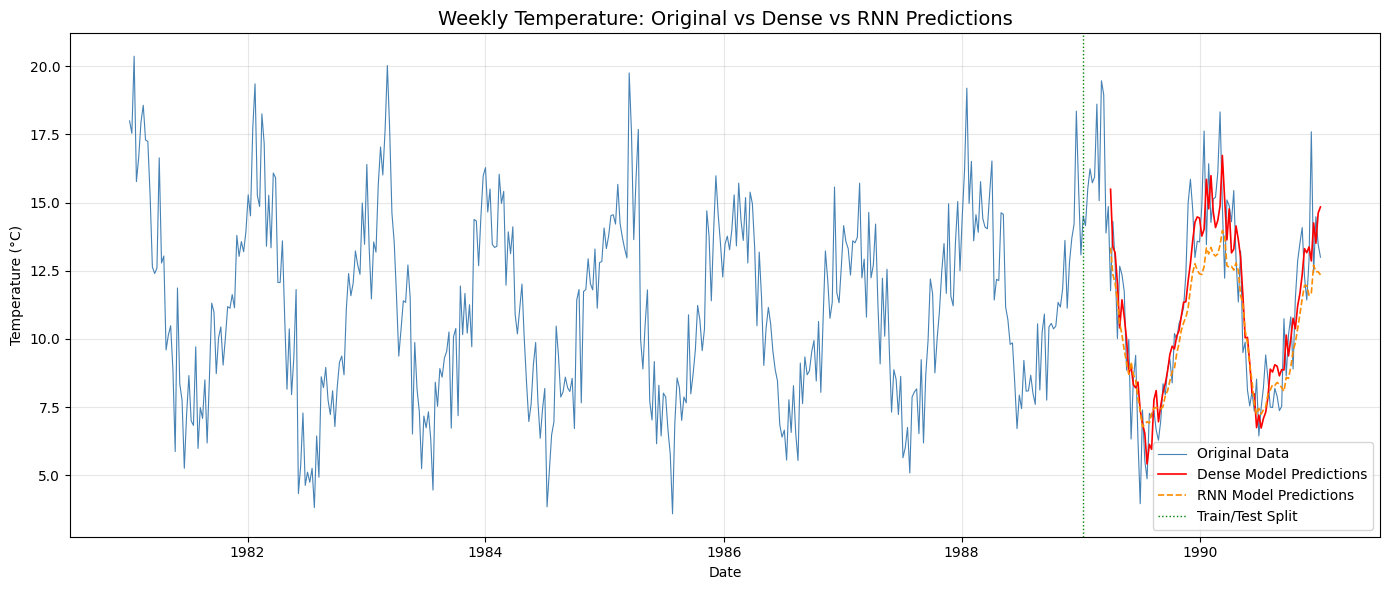

Comparison plot saved.


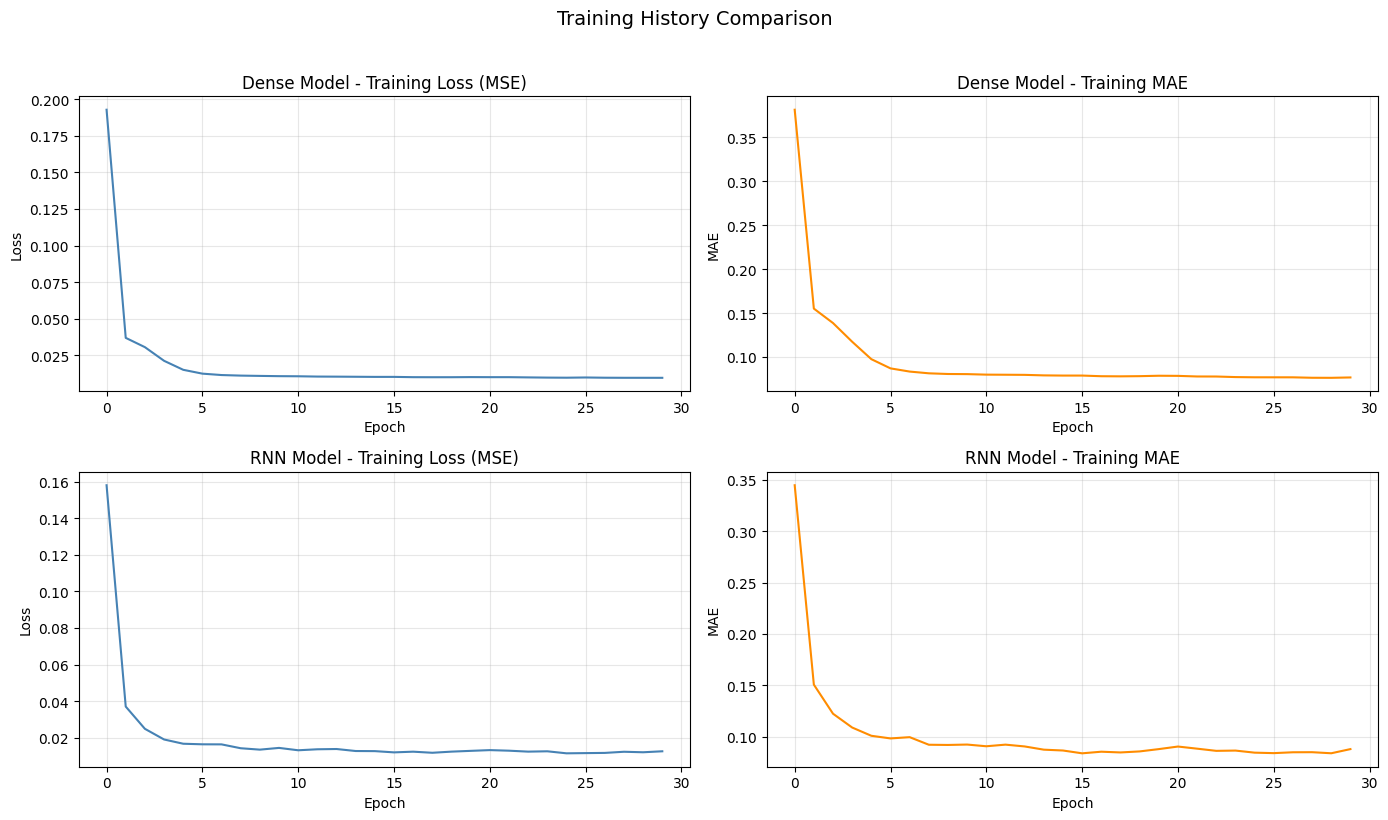

Training history comparison plot saved.

Final Training Metrics:
  Dense Model - Loss: 0.009512, MAE: 0.076671
  RNN Model   - Loss: 0.012495, MAE: 0.087832

Conclusion
  Dense Model - Loss(MSE): 0.009512, MAE: 0.076671 (~1.29°C)
  RNN Model   - Loss(MSE): 0.012495, MAE: 0.087832 (~1.47°C)

  Winner: Dense model (lower loss & MAE on training set)

  Analysis:
  - The Dense model achieves lower training loss and MAE than the RNN model.
  - With a small dataset (~523 weekly samples), the simpler Dense
    architecture generalizes well without the overhead of recurrent connections.
  - RNN's Dropout regularization further limits its fitting capacity on small data.


In [49]:
# ============================================================
# 步骤 13：绘制原始数据和两个模型的预测对比
# Step 13: Plot Original and Both Model Predictions
# ============================================================
print()
print("=" * LINE_WIDTH)
print("Step 13: Plot Original and Both Model Predictions")
print("=" * LINE_WIDTH)

# 确定两个模型预测的最短长度（确保对齐）
# Determine the shortest prediction length (ensure alignment)
min_pred_len = min(len(dense_predictions), len(rnn_predictions))
plot_time_index = test_time_index[:min_pred_len]

plt.figure(figsize=(14, 6))

# 蓝色实线：原始周平均气温
# Blue solid: original weekly average temperature
plt.plot(weekly_data.index, weekly_data.values, color='steelblue',
         linewidth=0.8, label='Original Data')

# 红色实线：Dense 模型预测
# Red solid: Dense model predictions
plt.plot(plot_time_index, dense_predictions[:min_pred_len].flatten(),
         color='red', linewidth=1.2, label='Dense Model Predictions')

# 橙色虚线：RNN 模型预测
# Orange dashed: RNN model predictions
plt.plot(plot_time_index, rnn_predictions[:min_pred_len].flatten(),
         color='darkorange', linewidth=1.2, linestyle='--', label='RNN Model Predictions')

# 绿色点线：训练/测试分界线
# Green dotted: train/test split boundary
plt.axvline(x=weekly_data.index[split_index], color='green', linestyle=':',
            linewidth=1.0, label='Train/Test Split')

plt.title('Weekly Temperature: Original vs Dense vs RNN Predictions', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'step13_both_predictions.png'), dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

print("Comparison plot saved.")

# ============================================================
# 训练历史对比图
# Training History Comparison
# ============================================================

# 绘制两个模型的训练损失和 MAE 对比
# Plot training loss and MAE comparison for both models
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dense 模型训练损失
# Dense model training loss
axes[0, 0].plot(dense_history.history['loss'], color='steelblue')
axes[0, 0].set_title('Dense Model - Training Loss (MSE)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Dense 模型 MAE
# Dense model MAE
axes[0, 1].plot(dense_history.history['mae'], color='darkorange')
axes[0, 1].set_title('Dense Model - Training MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].grid(True, alpha=0.3)

# RNN 模型训练损失
# RNN model training loss
axes[1, 0].plot(rnn_history.history['loss'], color='steelblue')
axes[1, 0].set_title('RNN Model - Training Loss (MSE)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

# RNN 模型 MAE
# RNN model MAE
axes[1, 1].plot(rnn_history.history['mae'], color='darkorange')
axes[1, 1].set_title('RNN Model - Training MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history_comparison.png'), dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

print("Training history comparison plot saved.")

# 打印最终训练指标
# Print final training metrics
print(f"\nFinal Training Metrics:")
print(f"  Dense Model - Loss: {dense_history.history['loss'][-1]:.6f}, MAE: {dense_history.history['mae'][-1]:.6f}")
print(f"  RNN Model   - Loss: {rnn_history.history['loss'][-1]:.6f}, MAE: {rnn_history.history['mae'][-1]:.6f}")

# ============================================================
# Conclusion
# ============================================================
dense_loss = dense_history.history['loss'][-1]
rnn_loss = rnn_history.history['loss'][-1]
dense_mae = dense_history.history['mae'][-1]
rnn_mae = rnn_history.history['mae'][-1]

# Convert normalized MAE to actual temperature deviation
temp_range = train_max - train_min
dense_mae_temp = dense_mae * temp_range
rnn_mae_temp = rnn_mae * temp_range

winner = "Dense" if dense_loss < rnn_loss else "RNN"

print()
print("=" * LINE_WIDTH)
print("Conclusion")
print("=" * LINE_WIDTH)
print(f"  Dense Model - Loss(MSE): {dense_loss:.6f}, MAE: {dense_mae:.6f} (~{dense_mae_temp:.2f}°C)")
print(f"  RNN Model   - Loss(MSE): {rnn_loss:.6f}, MAE: {rnn_mae:.6f} (~{rnn_mae_temp:.2f}°C)")
print()
print(f"  Winner: {winner} model (lower loss & MAE on training set)")
print()
print(f"  Analysis:")
print(f"  - The Dense model achieves lower training loss and MAE than the RNN model.")
print(f"  - With a small dataset (~{len(temp_values)} weekly samples), the simpler Dense")
print(f"    architecture generalizes well without the overhead of recurrent connections.")
print(f"  - RNN's Dropout regularization further limits its fitting capacity on small data.")
print("=" * LINE_WIDTH)